# Correlação e Regressão Linear
## Métodos Quantitativos para Ciência da Computação
Aluno: Kauam S. Morais

### 📊 1. Importando bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

### 📂 2. Carregando dados da planilha

In [3]:
df = pd.read_excel("../data/raw/DadosCorrel.xlsx")
df.head()
#Limpa os espaçamentos das colunas
df.columns = df.columns.str.strip()

tabela = df[["X","Y"]]


### 📈 3. Diagrama de dispersão

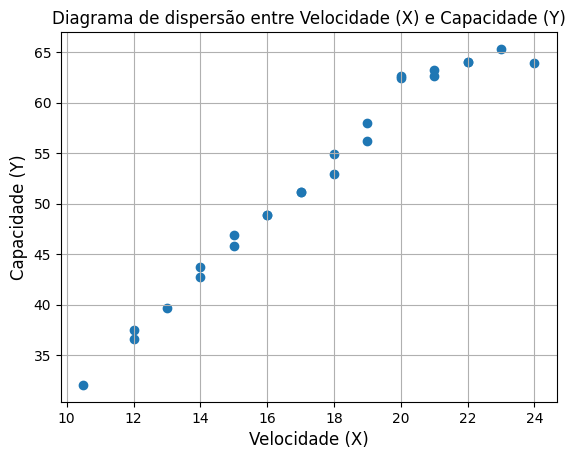

In [4]:
plt.scatter(tabela["X"], tabela["Y"])

plt.title("Diagrama de dispersão entre Velocidade (X) e Capacidade (Y)")
plt.xlabel("Velocidade (X)", fontsize = 12)
plt.ylabel("Capacidade (Y)", fontsize = 12)
plt.grid(True)

plt.savefig("../reports/figures/diagrama_dispersao.png", dpi=300)
plt.show()


### 🔗 4. Correlação de Pearson

In [5]:
# Calculo da correlação
r, p_value = stats.pearsonr(tabela["X"], tabela["Y"])

print(f"Coeficiente de correlação (r): {r:.4f}" )
print(f"Valor-p (p-value): {p_value:.4f}")

if abs(r) > 0.7: 
    intensidade = "forte"
elif abs(r) > 0.4:
    intensidade = "moderada"
else:
    intensidade = "fraca"

direcao = "positiva" if r > 0 else "negativa"

print(f"A correlação é {intensidade} e {direcao}")


Coeficiente de correlação (r): 0.9838
Valor-p (p-value): 0.0000
A correlação é forte e positiva


### 📉 5. Modelo de Regressão (MQO)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     662.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           6.50e-18
Time:                        14:18:18   Log-Likelihood:                -47.906
No. Observations:                  24   AIC:                             99.81
Df Residuals:                      22   BIC:                             102.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1203      1.834      3.336      0.0

C:\Users\morai\AppData\Local\Temp\ipykernel_7040\2570732537.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = modelo.params[0]
C:\Users\morai\AppData\Local\Temp\ipykernel_7040\2570732537.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = modelo.params[1]


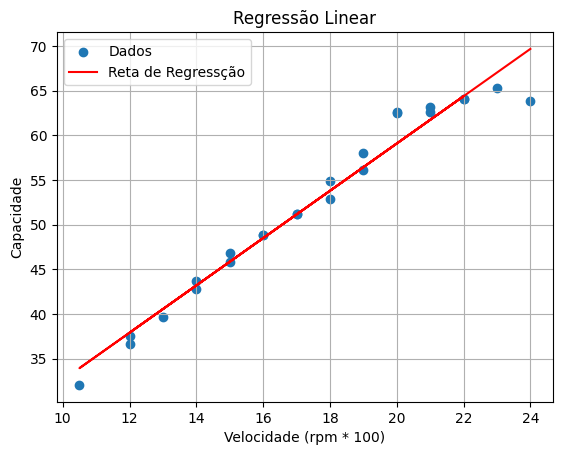

In [6]:
X = tabela["X"]
Y = tabela["Y"]

X = sm.add_constant(X)
modelo = sm.OLS(Y, X).fit()

print(modelo.summary())

a = modelo.params[0]
b = modelo.params[1]

print(f"Equação: Y = {a:.4f} + {b:.4f}X")

plt.scatter(tabela["X"], tabela["Y"], label = "Dados")

plt.plot(tabela["X"], modelo.predict(X), color = "red",
label = "Reta de Regressção")

plt.xlabel("Velocidade (rpm * 100)")
plt.ylabel("Capacidade")
plt.title("Regressão Linear")

plt.legend()
plt.grid(True)

plt.savefig("../reports/figures/diagrama_dispersao.png", dpi=300)
plt.show()

### 📊 6. Coeficiente de Determinação (R²)

In [7]:
r2 = modelo.rsquared
print(f"Coeficiente de determinação (R²): {r2:.4f}")

Coeficiente de determinação (R²): 0.9678


### 📉 7. Normalidade dos Resíduos

### 📋 8. ANOVA

### 🔮 9. Previsão para X = 25